In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision.transforms import AutoAugment, AutoAugmentPolicy
import matplotlib.pyplot as plt
from collections import Counter
import random, time, os

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

In [6]:
# AutoAugment train transform
train_transforms = T.Compose([
    T.RandomCrop(32, padding=4),                          # standard padding crop for CIFAR-10
    T.RandomHorizontalFlip(p=0.5),                        # kept from original
    AutoAugment(policy=AutoAugmentPolicy.CIFAR10),        # <-- learned policy
    T.ToTensor(),
    T.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

# Val transform (unchanged)
val_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=CIFAR10_MEAN, std=CIFAR10_STD),
])

In [7]:
DATA_DIR    = "/kaggle/working/data"
BATCH_SIZE  = 64
NUM_WORKERS = 2

full_train = torchvision.datasets.CIFAR10(DATA_DIR, train=True,  transform=train_transforms, download=True)
val_set    = torchvision.datasets.CIFAR10(DATA_DIR, train=False, transform=val_transforms,   download=True)

def make_subset(dataset, fraction, seed=SEED):
    n = int(len(dataset) * fraction)
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(dataset), size=n, replace=False).tolist()
    return Subset(dataset, indices)

loaders = {
    "10%":  DataLoader(make_subset(full_train, 0.10), batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
    "25%":  DataLoader(make_subset(full_train, 0.25), batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
    "50%":  DataLoader(make_subset(full_train, 0.50), batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
    "100%": DataLoader(full_train,                    batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True),
}
val_loader = DataLoader(val_set, batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("Dataset sizes:")
for k, dl in loaders.items():
    print(f"  {k:5s} -> {len(dl.dataset):,} samples, {len(dl):,} batches/epoch")
print(f"  {'val':5s} -> {len(val_set):,} samples")

100%|██████████| 170M/170M [10:38<00:00, 267kB/s]  


Dataset sizes:
  10%   -> 5,000 samples, 79 batches/epoch
  25%   -> 12,500 samples, 196 batches/epoch
  50%   -> 25,000 samples, 391 batches/epoch
  100%  -> 50,000 samples, 782 batches/epoch
  val   -> 10,000 samples


In [8]:
class CIFAR10_CNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(3,   32,  3, padding=1, bias=False), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32,  64,  3, padding=1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(64,  128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.classifier  = nn.Sequential(nn.Flatten(), nn.Dropout(p=dropout), nn.Linear(128*4*4, num_classes))

    def forward(self, x):
        return self.classifier(self.conv_block3(self.conv_block2(self.conv_block1(x))))

def build_model():
    model = CIFAR10_CNN().to(DEVICE)
    print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    return model

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        running_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += imgs.size(0)
    return running_loss / total, 100.0 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast("cuda"):
            outputs = model(imgs)
            loss    = criterion(outputs, labels)
        running_loss += loss.item() * imgs.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total   += imgs.size(0)
    return running_loss / total, 100.0 * correct / total

In [10]:
def run_experiment(subset_name, num_epochs=30):
    print(f"\n{'='*55}")
    print(f"  Experiment: {subset_name} subset  ({num_epochs} epochs)")
    print(f"{'='*55}")
    loader    = loaders[subset_name]
    model     = build_model()
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = torch.amp.GradScaler("cuda")
    history   = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, loader, criterion, optimizer, scaler)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)
        scheduler.step()
        for k, v in zip(["train_loss","train_acc","val_loss","val_acc"],
                        [tr_loss, tr_acc, vl_loss, vl_acc]):
            history[k].append(v)
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{num_epochs} | Train loss {tr_loss:.4f}  acc {tr_acc:.1f}% | "
                  f"Val loss {vl_loss:.4f}  acc {vl_acc:.1f}% | {time.time()-t0:.1f}s")
    best_val = max(history["val_acc"])
    print(f"\n  + Best val accuracy: {best_val:.2f}%")
    torch.save(model.state_dict(),
               f"/kaggle/working/cnn_autoaugment_{subset_name.replace('%','pct')}.pth")
    return history, best_val

In [11]:
EPOCHS  = 30
results = {}
for subset in ["10%", "25%", "50%", "100%"]:
    hist, best = run_experiment(subset, num_epochs=EPOCHS)
    results[subset] = {"history": hist, "best_val_acc": best}


  Experiment: 10% subset  (30 epochs)
Trainable parameters: 113,962
  Epoch   1/30 | Train loss 2.3457  acc 20.3% | Val loss 1.8587  acc 36.5% | 5.3s
  Epoch   5/30 | Train loss 1.9264  acc 35.2% | Val loss 1.6002  acc 49.7% | 3.8s
  Epoch  10/30 | Train loss 1.7810  acc 41.0% | Val loss 1.4838  acc 57.1% | 3.9s
  Epoch  15/30 | Train loss 1.6657  acc 47.8% | Val loss 1.4226  acc 59.3% | 4.0s
  Epoch  20/30 | Train loss 1.5975  acc 49.7% | Val loss 1.3346  acc 64.0% | 4.0s
  Epoch  25/30 | Train loss 1.5434  acc 53.3% | Val loss 1.3192  acc 65.2% | 3.8s
  Epoch  30/30 | Train loss 1.5416  acc 54.0% | Val loss 1.3073  acc 65.8% | 3.7s

  + Best val accuracy: 66.26%

  Experiment: 25% subset  (30 epochs)
Trainable parameters: 113,962
  Epoch   1/30 | Train loss 2.2023  acc 24.2% | Val loss 1.7521  acc 42.0% | 6.6s
  Epoch   5/30 | Train loss 1.7765  acc 41.9% | Val loss 1.4754  acc 56.9% | 6.8s
  Epoch  10/30 | Train loss 1.6076  acc 49.9% | Val loss 1.4196  acc 59.4% | 6.7s
  Epoch  15

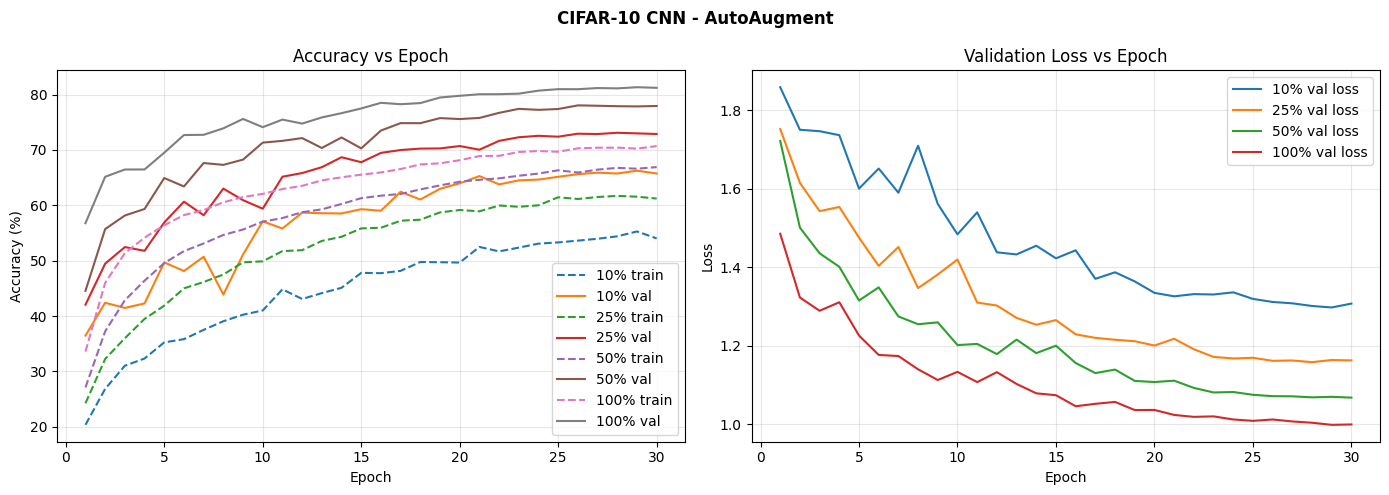


----------------------------------------
  Subset   Best Val Acc   Train Samples
----------------------------------------
     10%         66.26%           5,000
     25%         73.11%          12,500
     50%         78.06%          25,000
    100%         81.34%          50,000
----------------------------------------


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, data in results.items():
    h  = data["history"]
    ep = range(1, len(h["val_acc"]) + 1)
    axes[0].plot(ep, h["train_acc"], linestyle="--", label=f"{label} train")
    axes[0].plot(ep, h["val_acc"],   linestyle="-",  label=f"{label} val")
    axes[1].plot(ep, h["val_loss"],  linestyle="-",  label=f"{label} val loss")

axes[0].set_title("Accuracy vs Epoch"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy (%)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title("Validation Loss vs Epoch"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("CIFAR-10 CNN - AutoAugment", fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/autoaugment_curves.png", dpi=150)
plt.show()

print("\n" + "-"*40)
print(f"{'Subset':>8}  {'Best Val Acc':>13}  {'Train Samples':>14}")
print("-"*40)
for subset, data in results.items():
    n = len(loaders[subset].dataset)
    print(f"{subset:>8}  {data['best_val_acc']:>12.2f}%  {n:>14,}")
print("-"*40)